# Week3 - Domain RAG

## 아키텍처

```
START → agent → (tool_calls?) → tools → agent (loop)
                     ↓ (no)
               format_output → END
```

- `rag/` 모듈: 문서 로딩 → loader → embedding → ChromaDB 저장/검색
- `tools.py`: `search_minecraft`

In [6]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGSMITH_TRACING_V2"] = "false"

## 1. 벡터스토어 구축

In [7]:
from rag import build_index

vectorstore = build_index(data_path="./data", persist_directory="./chroma_db")
print("벡터스토어 구축 완료")

벡터스토어 구축 완료


## 2. 그래프 로드 및 시각화

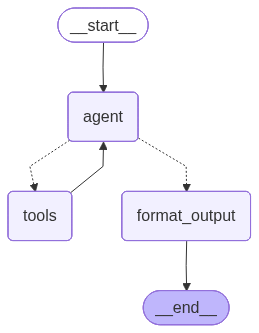

In [8]:
from graph import graph

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## 3. 단일 질문 테스트

In [9]:
def ask(question: str, thread_id: str = "1"):
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke({"messages": [("human", question)]}, config=config)

    output = result.get("structured_output")
    if output:
        print(f"[답변]\n{output.answer}")
        print(f"\n[신뢰도] {output.confidence:.2f}")
        if output.sources:
            print(f"\n[출처]")
            for s in output.sources:
                print(f"  - {s}")
        if output.tools_used:
            print(f"\n[사용 도구] {', '.join(output.tools_used)}")
    return result

result = ask("다이아몬드 검을 만드는 방법이 뭐야??")

[토큰] 입력: 1572 | 출력: 19 | 합계: 1591
[토큰] 입력: 2052 | 출력: 95 | 합계: 2147
[답변]
다이아몬드 검을 만드는 방법은 다음과 같습니다. 1개의 막대기와 2개의 다이아몬드가 필요합니다. 제작대에 이 재료들을 배열하면 다이아몬드 검을 만들 수 있습니다. 다이아몬드 검은 아이언 검보다 더 많은 피해를 주며 내구성도 높습니다. 또한 이 검은 넷herite 검으로 업그레이드할 수 있습니다.

[신뢰도] 0.90

[출처]
  - data/recipes/diamond_sword.txt
  - data/recipes/diamond_pickaxe.txt

[사용 도구] search_minecraft_wiki


## 4. 테스트 질문 3개

In [10]:
questions = [
    "다이아몬드 곡괭이를 만들려면 뭐가 필요해?",
    "엔더 드래곤을 잡으려면 어떻게 준비해야 해?",
    "블레이즈를 효율적으로 처치하는 방법은?",
]

for i, q in enumerate(questions, 1):
    print(f"\n{'='*60}")
    print(f"Q{i}. {q}")
    print('='*60)
    ask(q, thread_id=str(i))


Q1. 다이아몬드 곡괭이를 만들려면 뭐가 필요해?
[토큰] 입력: 2172 | 출력: 20 | 합계: 2192
[토큰] 입력: 2694 | 출력: 127 | 합계: 2821
[답변]
다이아몬드 곡괭이를 만들려면 3개의 다이아몬드와 2개의 막대기가 필요합니다. 이러한 재료들을 제작대에 올바르게 배열하면 다이아몬드 곡괭이를 만들 수 있습니다. 다이아몬드 곡괭이는 높은 채광 효율과 내구성을 가지고 있으며, 오브시디언과 고대 잔해 같은 특정 블록을 채굴할 수 있습니다. 또한, 이 곡괭이는 넷herite 곡괭이로 업그레이드할 수 있습니다.

[신뢰도] 0.90

[출처]
  - data/recipes/diamond_pickaxe.txt

[사용 도구] search_minecraft_wiki

Q2. 엔더 드래곤을 잡으려면 어떻게 준비해야 해?
[토큰] 입력: 1111 | 출력: 25 | 합계: 1136
[토큰] 입력: 1183 | 출력: 25 | 합계: 1208
[토큰] 입력: 1255 | 출력: 25 | 합계: 1280
[토큰] 입력: 1327 | 출력: 283 | 합계: 1610
[답변]
엔더 드래곤을 잡기 위한 준비는 다음과 같습니다.

1. **장비 강화**:
   - **무기**: 강력한 검(다이아몬드 이상)과 활을 준비하고 충분한 화살을 확보합니다.
   - **갑옷**: 높은 방어력을 제공하는 다이아몬드 또는 넷더라이트 갑옷을 착용하세요.

2. **아이템 준비**:
   - **포션**: 체력 회복, 힘, 속도 포션이 유용합니다.
   - **음식**: 체력을 회복할 수 있는 음식을 충분히 준비합니다.

3. **블록**: 
   - 엔더 드래곤의 회복을 위해 '엔더 크리스탈'을 파괴할 때 필요한 블록을 준비합니다.

4. **엔더 펄**: 
   - 전투 중 빠르게 이동할 수 있는 엔더 펄을 준비하세요.

5. **힐 장소 확보**: 
   - 전투 전에 안전하게 힐할 수 있는 장소를 확보해야 합니다.

이러한 준비를 통해 엔더 드래곤과의 전투에 효과